# 第十一次课后练习

<span style="color:red; font-weight:bold;">请将作业文件命名为 第十一次课后练习+姓名+学号.ipynb, 例如 第十一次课后练习+张三+1000000000.ipynb</span>

本次作业主要是练习一下网络软件包的基础使用。内容比较简单。大家可以抽空完成期中大作业的工作（数据集就是第九次作业发布的4个文件）。提交入口在五一开放。

# 第零部分 代码理解

请认真阅读代码，理解代码的功能，先写出预想的结果。运行并检验结果是否如预期。如果不如预期，请分析理解其中的原因

#### 总览
第零部分要全面，主要目的是带动同学们学习这些方法

第一部分则是对相关内容重点的一个考察

第二部分出一道全面综合的题目 或者 两道
    想出一道分词然后词频统计然后画图的题

#### 知识点
##### 图分析
网络模型简介

网络（图）建模基础
- 数据结构：邻接矩阵、邻接表
- 软件包：networkx

图参数

PageRank、HITS算法

图嵌入

##### 关系提取

实体关系抽取（Entity and Relation Extraction，ERE），分为两个子任务：

命名实体识别（NER）

和实体间关系（三元组）的抽取

S N O W B A L L算法

因果句模式匹配-中文


#### 题目

1. 建图：两种数据结构
   1. nx.Graph()
   2. nx.draw()
   3. 从其他数据源接入数据
      1. from numpy
      2. from pandas
2. 图算法：CENTRALITY
   1. 点度中心度
   2. 特征向量中心度
   3. 接近中心度
   4. 介度中心度（betweeness）
3. PageRank、HITS算法
4. 最短路
   1. （点对）最短路
   2. 单源最短路
   3. 图最短路（All shortest path）
5. 可视化

6.  图的空间嵌入
    1.  PMI（JACCARD）关联的PCA近邻嵌入 

## **0.1** 社交网络基础图构建与可视化
    阅读下面代码，观察运行的结果，解释出现这个结果的原因。

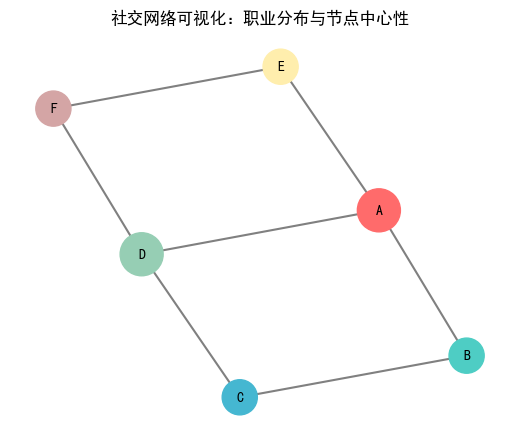

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# 设置字体为黑体
plt.rcParams['font.sans-serif'] = ['SimHei']
# 解决负号显示为方块的问题
# plt.rcParams['axes.unicode_minus'] = False

# 1. 数据准备
edges_df = pd.DataFrame({
    'source': ['A', 'B', 'C', 'D', 'A', 'E', 'F'],
    'target': ['B', 'C', 'D', 'A', 'E', 'F', 'D']
})
nodes_df = pd.DataFrame({
    'user': ['A', 'B', 'C', 'D', 'E', 'F'],
    'occupation': ['学生', '工程师', '设计师', '教师', '医生', '自由职业']
})

# 2. 构建无向图
G = nx.Graph()

# 3. 添加节点与边
G.add_edges_from(list(zip(edges_df['source'], edges_df['target'])))

# 4. 添加节点属性（职业）
for _, row in nodes_df.iterrows():
    G.nodes[row['user']]['occupation'] = row['occupation'] 

# 5. 可视化设计
plt.figure(figsize=(5, 4))
pos = nx.spring_layout(G, seed=42)  

# 6. 根据节点度中心性设置节点大小
node_degree = dict(nx.degree_centrality(G))  
node_size = [v * 1600 for v in node_degree.values()]

# 7. 根据职业设置节点颜色
occupation_color = {
    '学生': '#FF6B6B', '工程师': '#4ECDC4', 
    '设计师': '#45B7D1', '教师': '#96CEB4',
    '医生': '#FFEEAD', '自由职业': '#D4A5A5'
}
node_color = [occupation_color[G.nodes[n]['occupation']] for n in G.nodes()]

# 8. 绘制网络图
nx.draw(G, pos, with_labels=True, node_size=node_size, node_color=node_color, 
        edge_color='grey', width=1.5, font_size=10, font_weight='bold')
plt.title("社交网络可视化：职业分布与节点中心性")
plt.axis('off')
plt.show()

建立用户与用户之间联系的无向图，然后再把用户对应职业对应的染色染上

## **0.2** 社交网络关键节点识别与中心性对比
    阅读下面代码，观察运行的结果，解释出现这个结果的原因。

C:\Users\32698\AppData\Local\Temp\ipykernel_47996\4011570441.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


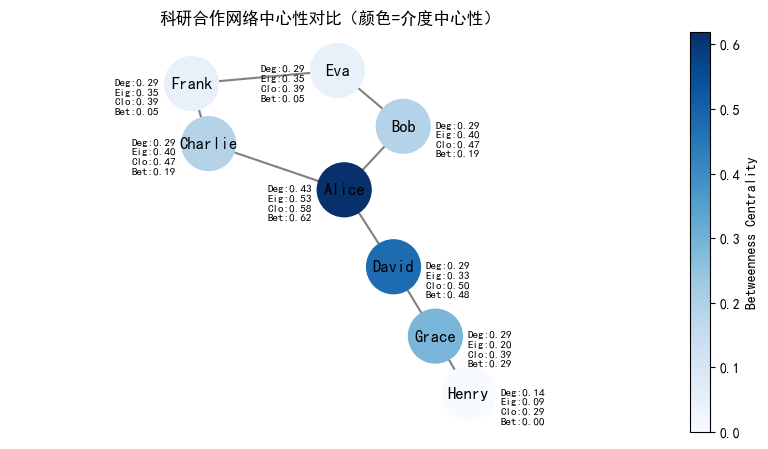

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# 1. 构建科研合作网络
G = nx.Graph()
edges = [
    ("Alice", "Bob"), ("Alice", "Charlie"), ("Alice", "David"),
    ("Bob", "Eva"), ("Charlie", "Frank"), ("David", "Grace"),
    ("Eva", "Frank"), ("Grace", "Henry")
]
G.add_edges_from(edges)

# 2. 计算四种中心性指标
# ----------------------------
# 点度中心度（直接连接数）
degree_centrality = nx.degree_centrality(G)  # 答案1

# 特征向量中心度（邻居节点重要性）
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=100)  # 答案2

# 接近中心度（到其他节点的平均距离）
closeness_centrality = nx.closeness_centrality(G)  # 答案3（默认已归一化）

# 介度中心度（桥接不同社区的能力）
betweenness_centrality = nx.betweenness_centrality(G, normalized=True)  # 答案4

# 3. 结果对比与可视化
plt.figure(figsize=(8, 4))
# 计算布局时增加缓冲区，设置更大的缩放比例让节点更靠近中心
pos = nx.spring_layout(G, seed=42, scale=1.5)


# 绘制网络图（颜色映射介度中心性）
node_color = list(betweenness_centrality.values())
# 设置画布大小，防止文字偏移出图片

nx.draw(G, pos, 
        with_labels=True, 
        node_size=1500,
        node_color=node_color, 
        cmap=plt.cm.Blues,
        edge_color='gray', 
        width=1.5)

# 添加中心性标注
labels = {n: f"Deg:{degree_centrality[n]:.2f}\nEig:{eigenvector_centrality[n]:.2f}\nClo:{closeness_centrality[n]:.2f}\nBet:{betweenness_centrality[n]:.2f}" 
          for n in G.nodes()}
# 智能调整标签位置，对于左侧节点向左偏移更多
labels_pos = {}
for n in G.nodes():
    # 根据节点x坐标动态调整水平偏移
    if pos[n][0] < 0:  # 左侧节点
        labels_pos[n] = (pos[n][0] - 0.15, pos[n][1] - 0.1)  # 左侧节点向左偏移更多
    elif pos[n][0] > 0:  # 右侧节点
        labels_pos[n] = (pos[n][0] + 0.15, pos[n][1] - 0.1)  # 右侧节点向右偏移
    else:  # 中间节点
        labels_pos[n] = (pos[n][0], pos[n][1] - 0.15)  # 中间节点向下偏移

nx.draw_networkx_labels(G, labels_pos, labels=labels, font_size=8, font_color='black')

# 创建规范化器，范围与节点颜色值对应
norm = colors.Normalize(vmin=min(betweenness_centrality.values()), 
                       vmax=max(betweenness_centrality.values()))


plt.title("科研合作网络中心性对比（颜色=介度中心性）")
plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=norm), 
             ax=plt.gca(), 
            label="Betweenness Centrality")

# 设置坐标轴范围，确保有足够空间显示标签
x_values = [pos[node][0] for node in G.nodes()]
y_values = [pos[node][1] for node in G.nodes()]
x_margin = 0.5  # 水平边距
y_margin = 0.3  # 垂直边距
plt.xlim(min(x_values) - x_margin, max(x_values) + x_margin)
plt.ylim(min(y_values) - y_margin, max(y_values) + y_margin)

# 应用紧凑布局
plt.tight_layout(pad=2.0)
plt.axis('off')
plt.show()

## **0.3** PageRank算法

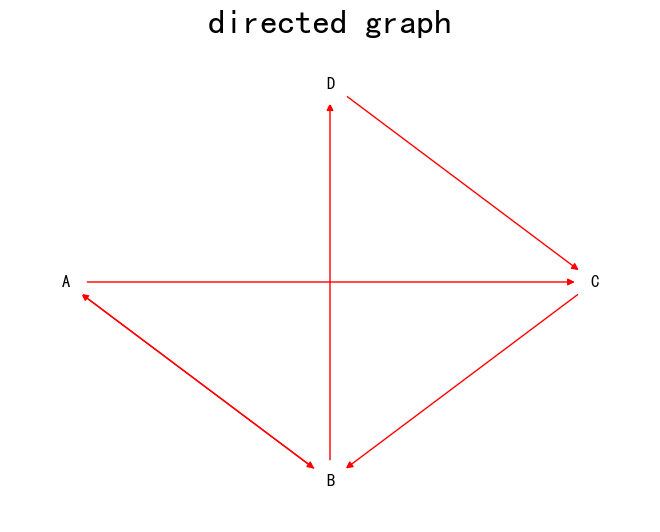

PageRank: {'A': 0.18669946835938991, 'B': 0.35105903526129834, 'C': 0.2755420280199218, 'D': 0.18669946835938991}
HITS Hubs: {'A': 0.5, 'B': 0.0, 'C': 0.25, 'D': 0.25}
HITS Authorities: {'A': 0.0, 'B': 0.5, 'C': 0.5, 'D': 0.0}


In [3]:
import numpy as np 
import networkx as nx
import matplotlib.pyplot as plt
import pylab
# 创建有向图
G = nx.DiGraph()

# 有向图之间边的关系
edges = [("A", "B"), ("A", "C"), ("B", "A"), ("B", "D"), ("C", "B"), ("D", "C")]

for edge in edges:
     G.add_edge(edge[0], edge[1])


pos=nx.shell_layout(G)
nx.draw(G,pos,with_labels=True, node_color='white', edge_color='red', node_size=800, alpha=1 )
pylab.title('directed graph',fontsize=25)
pylab.show()

# pagerank算法
pagerank = nx.pagerank(G, alpha=0.85)
print("PageRank:", pagerank)

# HITS算法
hubs, authorities = nx.hits(G)
print("HITS Hubs:", hubs)
print("HITS Authorities:", authorities)

## **0.4** 最短路
    阅读下面代码，观察运行的结果，解释出现这个结果的原因。

A到E的最短路径及距离: (['A', 'C', 'D', 'E'], 7)
A到所有节点距离: {'A': 0, 'B': 3, 'C': 2, 'D': 3, 'E': 7}
全源最短距离矩阵:
 [[ 0.  3.  2.  3.  7.]
 [inf  0. inf  5.  9.]
 [inf inf  0.  1.  5.]
 [inf inf inf  0.  4.]
 [inf inf inf inf  0.]]


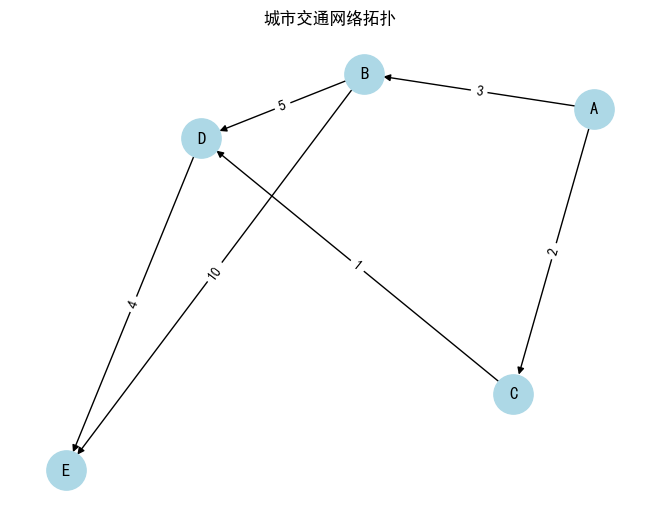

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. 构建带权交通网络
G = nx.DiGraph()
edges = [
    ("A", "B", 3), ("A", "C", 2), ("B", "D", 5),
    ("C", "D", 1), ("D", "E", 4), ("B", "E", 10)
]
G.add_weighted_edges_from(edges)

# 2. 点对最短路（Dijkstra算法）
def point_to_point_shortest(graph, start, end):
    try:
        path = nx.shortest_path(graph, start, end, weight='weight') 
        length = nx.shortest_path_length(graph, start, end, weight='weight')
        return path, length
    except nx.NetworkXNoPath:
        return "不可达", float('inf')

# 3. 单源最短路（Bellman-Ford算法）
def single_source_shortest(graph, start):
    try:
        lengths = nx.single_source_bellman_ford_path_length(graph, start, weight='weight')
        return lengths
    except nx.NetworkXUnbounded:
        return "存在负权环"

# 4. 全图最短路（Floyd-Warshall算法）
def all_pairs_shortest(graph):
    return nx.floyd_warshall_numpy(graph, weight='weight')  

# 验证与可视化
print("A到E的最短路径及距离:", point_to_point_shortest(G, "A", "E"))  # 预期输出：(['A', 'C', 'D', 'E'], 7)
print("A到所有节点距离:", single_source_shortest(G, "A"))          # 预期输出：{'A':0, 'B':3, 'C':2, 'D':3, 'E':7}
print("全源最短距离矩阵:\n", all_pairs_shortest(G))

# 绘制网络图（含权重标注）
pos = nx.spring_layout(G, seed=10)  # 布局算法
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=800)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("城市交通网络拓扑")
plt.show()


## **0.5** 图的空间嵌入
    阅读下面代码，观察运行的结果，解释出现这个结果的原因。

方差贡献率: [0.34233656 0.21397033]


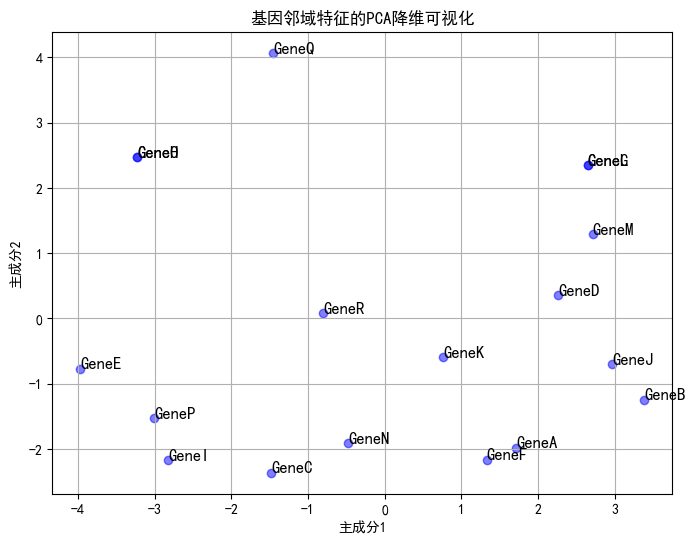

In [5]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 基因邻域特征集（示例数据）
gene_sets = {
    "GeneA": {"Cancer", "Immune", "Metabolism"},
    "GeneB": {"Immune", "Metabolism", "Aging"},
    "GeneC": {"Cancer", "Aging", "Neuro"},
    "GeneD": {"Metabolism", "Neuro", "Immune"},
    "GeneE": {"Cancer", "Apoptosis", "Signaling"},
    "GeneF": {"Inflammation", "Immune", "Aging"},
    "GeneG": {"Metabolism", "Diabetes", "Hormone"},
    "GeneH": {"Neuro", "Development", "Signaling"},
    "GeneI": {"Cancer", "Oxidative", "Stress"},
    "GeneJ": {"Cardiovascular", "Metabolism", "Aging"},
    "GeneK": {"Immune", "Infection", "Inflammation"},
    "GeneL": {"Bone", "Metabolism", "Hormone"},
    "GeneM": {"Liver", "Metabolism", "Detoxification"},
    "GeneN": {"Kidney", "Aging", "Stress"},
    "GeneO": {"Neuro", "Signaling", "Development"},
    "GeneP": {"Cancer", "Apoptosis", "Cell Cycle"},
    "GeneQ": {"Reproduction", "Hormone", "Development"},
    "GeneR": {"Immune", "Signaling", "Infection"}
}

# 2. 计算Jaccard相似性矩阵
def jaccard(set_a, set_b):
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union != 0 else 0

n_genes = len(gene_sets)
genes = list(gene_sets.keys())
jaccard_matrix = np.zeros((n_genes, n_genes))
for i in range(n_genes):
    for j in range(n_genes):
        jaccard_matrix[i][j] = jaccard(gene_sets[genes[i]], gene_sets[genes[j]])

# 3. PMI增强属性关联（假设共现统计）
# 示例：PMI计算（基于全局共现频次）
pmi_matrix = np.log((jaccard_matrix + 1e-6) / (np.mean(jaccard_matrix) ** 2))  # 简化计算

# 4. 联合相似性矩阵（α=0.7）
alpha = 0.7
combined_matrix = alpha * jaccard_matrix + (1 - alpha) * pmi_matrix

# 5. PCA降维与可视化
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_matrix)
pca = PCA(n_components=2)
embeddings = pca.fit_transform(combined_scaled)

# 输出主成分解释率
print("方差贡献率:", pca.explained_variance_ratio_)

# 可视化
plt.figure(figsize=(8, 6))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c='blue', alpha=0.5)
for i, gene in enumerate(genes):
    plt.annotate(gene, (embeddings[i, 0], embeddings[i, 1]), fontsize=12)
plt.title("基因邻域特征的PCA降维可视化")
plt.xlabel("主成分1")
plt.ylabel("主成分2")
plt.grid()
plt.show()

计算基因相似度

# 第一部分 基础练习

## **1.1** 基于networkx建图

In [ ]:
import networkx as nx
import pandas as pd

# 任务1：初始化无向图对象
 # 填空1（创建空图对象）
graph = nx.Graph()  # 创建空图对象
# 任务2：添加三条边（A-B, B-C, C-D）
  # 填空2（边添加方法）
graph.add_edges_from([('A', 'B'), ('B', 'C'), ('C', 'D')])
# 设置可视化参数
pos = nx.spring_layout(graph, seed=42)  # 布局算法
nx.draw(graph, pos, with_labels=True, node_color='skyblue')  # （节点颜色参数）

# 从DataFrame添加边
edges_data = pd.DataFrame({
    'from': ['X', 'Y', 'Z'], 
    'to': ['Y', 'Z', 'X']
})
graph.add_edges_from(zip(edges_data['from'], edges_data['to']))  # 提取边元组列表）

# 任务3：添加孤立节点
graph.add_node('W')  # 填空3（添加单个节点W）

## **1.2** Centrality代码填空题

In [6]:
import networkx as nx

# 任务1：计算点度中心性
def compute_degree_centrality(graph):
    return nx.degree_centrality(graph)  # 计算节点度中心性
# 任务2：计算特征向量中心性（需处理可能的收敛问题）
def compute_eigenvector_centrality(graph):
    return nx.eigenvector_centrality(graph, max_iter=100)  #

# 任务3：计算归一化接近中心性
def compute_closeness_centrality(graph):
    return nx.closeness_centrality(graph)  # 计算归一化接近中心性

# 任务4：计算非归一化介度中心性
def compute_betweenness_centrality(graph):
    return nx.betweenness_centrality(graph)  # 计算非归一化介度中心性

# 综合排序输出
G = nx.star_graph(5)  # 星型图（中心节点0）
centralities = {
    "Degree": compute_degree_centrality(G),
    "Eigenvector": compute_eigenvector_centrality(G),
    "Betweenness": compute_betweenness_centrality(G)
}
result = {}
for metric, values in centralities.items():
    result[metric] = max(values, key=values.get)  # 取最大值
    print(f"{metric} Top Node: {max(values, key=values.get)}")

Degree Top Node: 0
Eigenvector Top Node: 0
Betweenness Top Node: 0


In [7]:
assert result == {'Degree': 0, 'Eigenvector': 0, 'Betweenness': 0}, "测试失败！"

## **1.3** PageRank算法

In [8]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

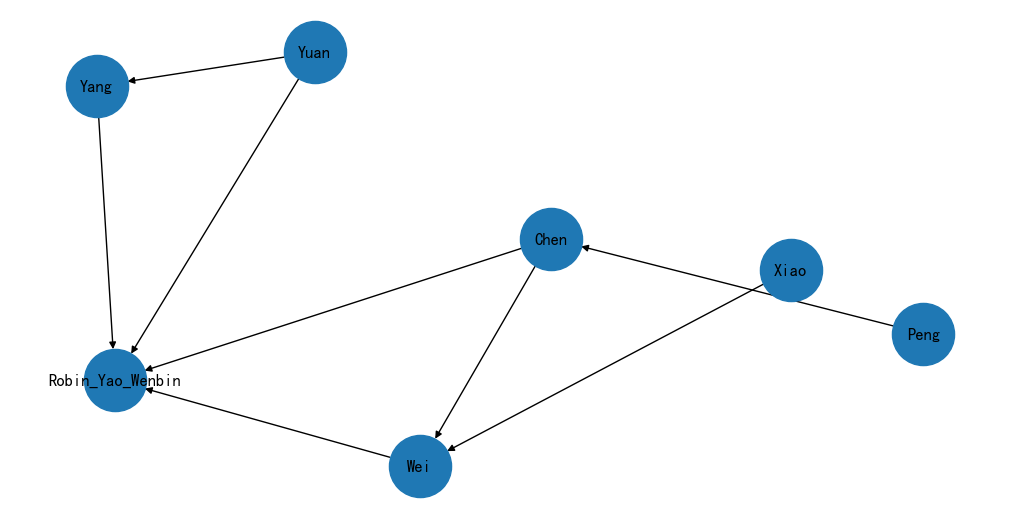

{'Robin_Yao_Wenbin': 0.18922111166411845,
 'Wei': 0.15512870087545896,
 'Yang': 0.13489452111126102,
 'Yuan': 0.1254833120633197,
 'Xiao': 0.1254833120633197,
 'Chen': 0.14430573015920237,
 'Peng': 0.1254833120633197}

In [9]:
plt.figure(figsize=(10,5))

G = nx.DiGraph()
G.add_nodes_from(['Robin_Yao_Wenbin','Wei','Yang','Yuan','Xiao','Chen','Peng'])    #加点集合
G.add_edge('Wei' ,'Robin_Yao_Wenbin' )   #一次添加一条边
G.add_edge('Yang' ,'Robin_Yao_Wenbin' )   #一次添加一条边
G.add_edge('Yuan' ,'Robin_Yao_Wenbin' )   #一次添加一条边
G.add_edge('Chen' ,'Robin_Yao_Wenbin' )   #一次添加一条边
G.add_edge('Peng' ,'Chen' )   #一次添加一条边
G.add_edge('Xiao' ,'Wei' )   #一次添加一条边
G.add_edge('Chen' ,'Wei' )   #一次添加一条边
G.add_edge('Yuan' ,'Yang' )   #一次添加一条边
nx.draw(G, with_labels=True , node_size = 2000)
plt.show()

pr =  nx.pagerank(G, alpha=0.15)                                   # 填空：计算PageRank，0.15随机游走

pr

In [10]:
assert pr['Robin_Yao_Wenbin'] > pr['Wei'] > pr['Chen'] > pr['Yang'] > pr['Yuan'] == pr['Peng'] == pr['Xiao'], "PageRank排序错误"

## **1.4** 最短路（本题阅读代码理解）

小明到小美的最优路径: ['小明', '小红', '小芳', '小美']
小红的社交圈距离: {'小红': 0, '小芳': 2, '小美': 6}


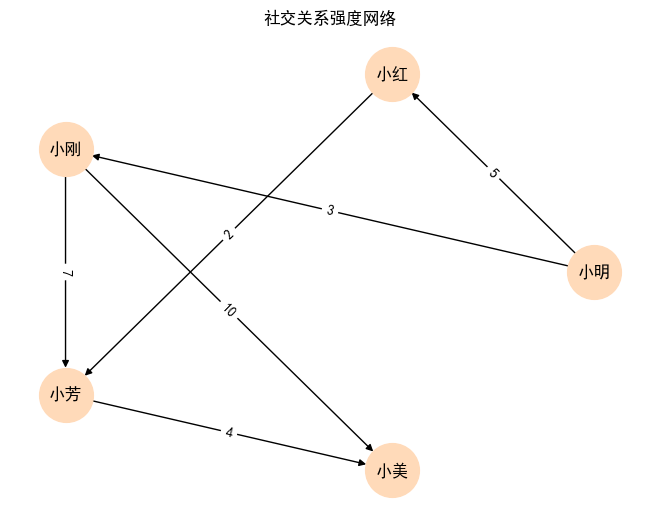

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 构建社交关系网络
G = nx.DiGraph()  # 创建有向图对象
edges = [
    ("小明", "小红", {"weight":5}), 
    ("小明", "小刚", {"weight":3}), 
    ("小红", "小芳", {"weight":2}),
    ("小刚", "小芳", {"weight":7}),
    ("小芳", "小美", {"weight":4}),
    ("小刚", "小美", {"weight":10})
]
G.add_edges_from(edges)  # 添加带属性边

# 2. 亲密路径计算
def find_closest_friend(graph, start):
    try:
        return nx.single_source_bellman_ford_path_length(graph, start, weight='weight')  # 单源最短路算法 bellman-ford
    except nx.NetworkXUnbounded:
        return "存在异常关系链"

# 3. 验证与可视化
xm2xm = nx.shortest_path(G, "小明", "小美", weight='weight')  # 计算小明到小美的最短路径长度
print("小明到小美的最优路径:", nx.shortest_path(G, "小明", "小美", weight='weight'))  # 
xh_closest = find_closest_friend(G, "小红")
print("小红的社交圈距离:", xh_closest)

# 绘制关系网络图
pos = nx.circular_layout(G)  # 圆形布局
nx.draw(G, pos, with_labels=True, node_color='peachpuff', node_size=1500)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))  # 
plt.title("社交关系强度网络")  # 
plt.show()

In [12]:
assert xh_closest == {'小红': 0, '小芳': 2, '小美': 6}, "单源最短路算法计算结果不正确"
assert xm2xm == ['小明', '小红', '小芳', '小美'], "最优路径计算结果不正确"

## **1.5** 图的空间嵌入

Jaccard相似度矩阵：
       GeneA     GeneB  GeneC     GeneD  GeneE
GeneA   1.00  0.000000   0.50  0.250000   0.75
GeneB   0.00  1.000000   0.25  0.333333   0.20
GeneC   0.50  0.250000   1.00  0.000000   0.40
GeneD   0.25  0.333333   0.00  1.000000   0.50
GeneE   0.75  0.200000   0.40  0.500000   1.00
PCA结果：
[[ 1.86524552  0.15213762]
 [-2.57294091 -0.89255041]
 [ 0.74747958 -2.0304724 ]
 [-1.32100078  1.77257326]
 [ 1.2812166   0.99831194]]


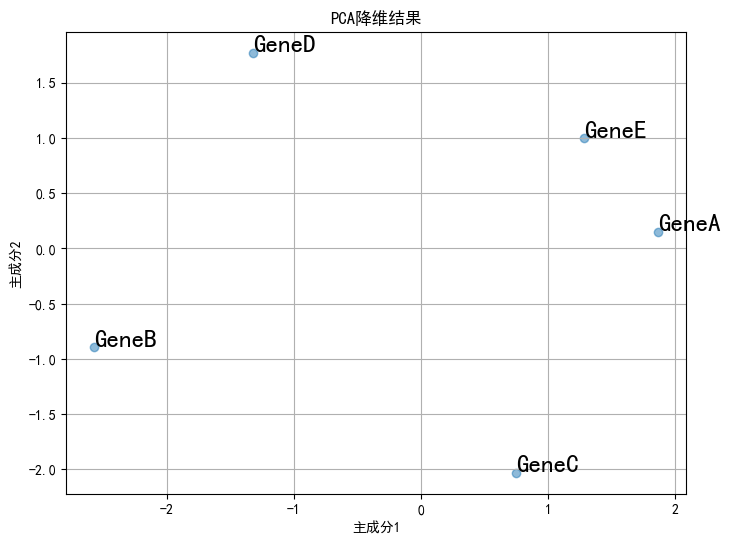

In [13]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 数据生成
data = {
    'GeneA': [1, 0, 1, 0, 1],
    'GeneB': [0, 1, 0, 1, 0],
    'GeneC': [1, 1, 0, 0, 1],
    'GeneD': [0, 0, 1, 1, 0],
    'GeneE': [1, 0, 1, 1, 1]
}
df = pd.DataFrame(data)

# 计算Jaccard相似度矩阵
def jaccard_similarity(data):
    n = data.shape[1]
    jaccard_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            intersection = np.sum(np.logical_and(data.iloc[:, i], data.iloc[:, j]))
            union = np.sum(np.logical_or(data.iloc[:, i], data.iloc[:, j]))
            jaccard_matrix[i, j] = intersection / union if union != 0 else 0
    return pd.DataFrame(jaccard_matrix, columns=data.columns, index=data.columns)

# 计算Jaccard相似度矩阵
jaccard_matrix = jaccard_similarity(df)
print("Jaccard相似度矩阵：")
print(jaccard_matrix)

# PCA降维
scaler = StandardScaler()
scaled_data = scaler.fit_transform(jaccard_matrix)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

print("PCA结果：")
print(pca_result)

# 可视化PCA结果
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
for i, gene in enumerate(jaccard_matrix.columns):
    plt.annotate(gene, (pca_result[i, 0], pca_result[i, 1]), fontsize=18)
plt.title("PCA降维结果")
plt.xlabel("主成分1")
plt.ylabel("主成分2")

plt.grid()
plt.show()

In [15]:
assert jaccard_matrix.values[0][1] == 0, "Jaccard相似度计算错误"
assert jaccard_matrix.values[0][2] == 0.5, "Jaccard相似度计算错误"
assert jaccard_matrix.values[0][3] == 0.25, "Jaccard相似度计算错误"
assert jaccard_matrix.values[0][0] == 1, "Jaccard相似度计算错误"

这个assert还弄错了我改了，肯定是自己和自己相似度为1